In [49]:
pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [50]:
import yfinance as yf
print('yfinance is ready')

yfinance is ready


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

import math
import random
import warnings
warnings.filterwarnings('ignore')

In [52]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

In [53]:
TICKER = 'AAPL'

START_DATE = '2015-01-01'
END_DATE = '2025-01-01'

df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2015-01-02,24.171755,27.332500,27.860001,26.837500,27.847500,212818400
2015-01-05,23.490801,26.562500,27.162500,26.352501,27.072500,257142000
2015-01-06,23.493011,26.565001,26.857500,26.157499,26.635000,263188400
2015-01-07,23.822435,26.937500,27.049999,26.674999,26.799999,160423600
2015-01-08,24.737743,27.972500,28.037500,27.174999,27.307501,237458000


In [54]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

In [55]:
df = df.reset_index()

In [56]:
df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-01-02,24.171755,27.332500,27.860001,26.837500,27.847500,212818400
1,2015-01-05,23.490801,26.562500,27.162500,26.352501,27.072500,257142000
2,2015-01-06,23.493011,26.565001,26.857500,26.157499,26.635000,263188400
3,2015-01-07,23.822435,26.937500,27.049999,26.674999,26.799999,160423600
4,2015-01-08,24.737743,27.972500,28.037500,27.174999,27.307501,237458000


In [57]:
df.shape

(2516, 7)

In [58]:
df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [59]:
df.dtypes

Price
Date         datetime64[ns]
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
dtype: object

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2516 non-null   datetime64[ns]
 1   Adj Close  2516 non-null   float64       
 2   Close      2516 non-null   float64       
 3   High       2516 non-null   float64       
 4   Low        2516 non-null   float64       
 5   Open       2516 non-null   float64       
 6   Volume     2516 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 137.7 KB


In [61]:
df.describe()

Price,Date,Adj Close,Close,High,Low,Open,Volume
count,2516,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2.516000e+03
mean,2019-12-31 19:03:31.764706048,93.604149,96.363971,97.299699,95.323938,96.275646,1.170853e+08
min,2015-01-02 00:00:00,20.548149,22.584999,22.917500,22.367500,22.500000,2.323470e+07
25%,2017-07-02 06:00:00,35.127337,37.639375,38.040001,37.295626,37.606874,7.105610e+07
50%,2020-01-01 00:00:00,64.213238,66.661251,67.281250,65.807503,66.549999,1.003646e+08
75%,2022-06-30 06:00:00,149.826164,152.772503,154.564999,150.812504,152.572506,1.426216e+08
max,2024-12-31 00:00:00,257.153809,259.019989,260.100006,257.630005,258.190002,6.488252e+08
std,NaN,65.263645,65.255230,65.849313,64.567788,65.174986,6.839614e+07


In [62]:
df.isna().sum()

Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

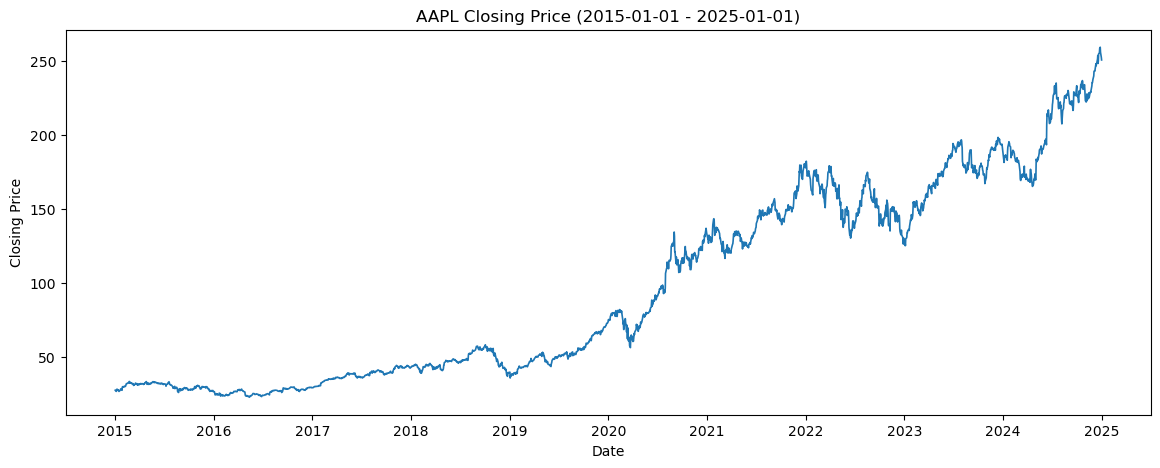

In [63]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close'], linewidth=1.2)
plt.title(f"{TICKER} Closing Price ({START_DATE} - {END_DATE})")
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

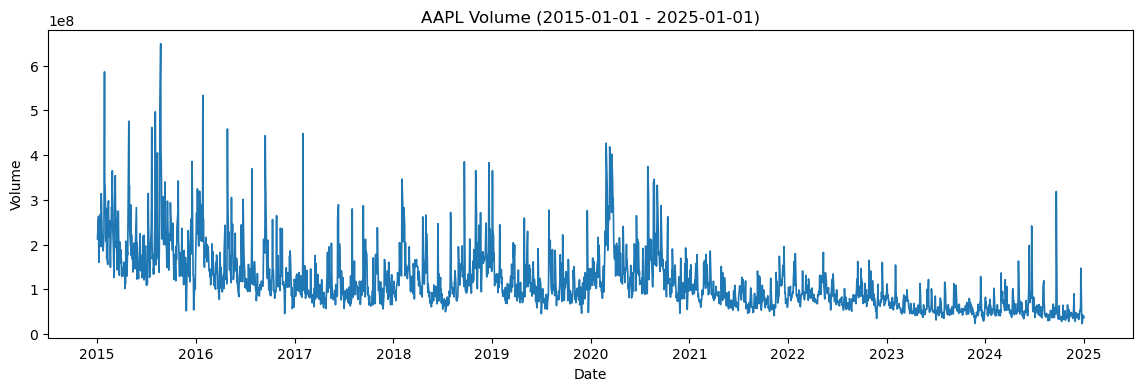

In [64]:
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['Volume'], linewidth=1.2)
plt.title(f"{TICKER} Volume ({START_DATE} - {END_DATE})")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

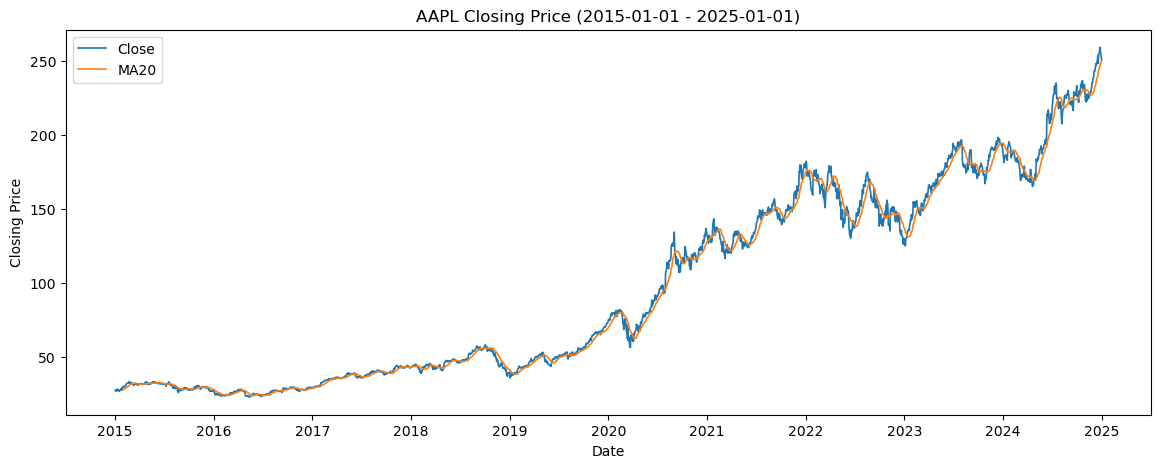

In [65]:
df['MA20'] = df['Close'].rolling(20).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close'], linewidth=1.2, label='Close')
plt.plot(df['Date'], df['MA20'], linewidth=1.2, label='MA20')
plt.title(f"{TICKER} Closing Price ({START_DATE} - {END_DATE})")
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

In [66]:
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,MA20
0,2015-01-02,24.171755,27.332500,27.860001,26.837500,27.847500,212818400,NaN
1,2015-01-05,23.490801,26.562500,27.162500,26.352501,27.072500,257142000,NaN
2,2015-01-06,23.493011,26.565001,26.857500,26.157499,26.635000,263188400,NaN
3,2015-01-07,23.822435,26.937500,27.049999,26.674999,26.799999,160423600,NaN
4,2015-01-08,24.737743,27.972500,28.037500,27.174999,27.307501,237458000,NaN
...,...,...,...,...,...,...,...,...
2511,2024-12-24,256.339752,258.200012,258.209991,255.289993,255.490005,23234700,246.293500
2512,2024-12-26,257.153809,259.019989,260.100006,257.630005,258.190002,27237100,247.491499
2513,2024-12-27,253.748535,255.589996,258.700012,253.059998,257.829987,42355300,248.524500
2514,2024-12-30,250.382965,252.199997,253.500000,250.750000,252.229996,35557500,249.267999


In [67]:
close_prices = df[['Close']].values

In [68]:
print(close_prices[:5])

[[27.33250046]
 [26.5625    ]
 [26.56500053]
 [26.9375    ]
 [27.97249985]]


In [69]:
demo_scaler = MinMaxScaler(feature_range=(0, 1))
demo_scaled = demo_scaler.fit_transform(close_prices)
print(demo_scaled[:5])

[[0.02007952]
 [0.01682281]
 [0.01683339]
 [0.01840887]
 [0.02278639]]


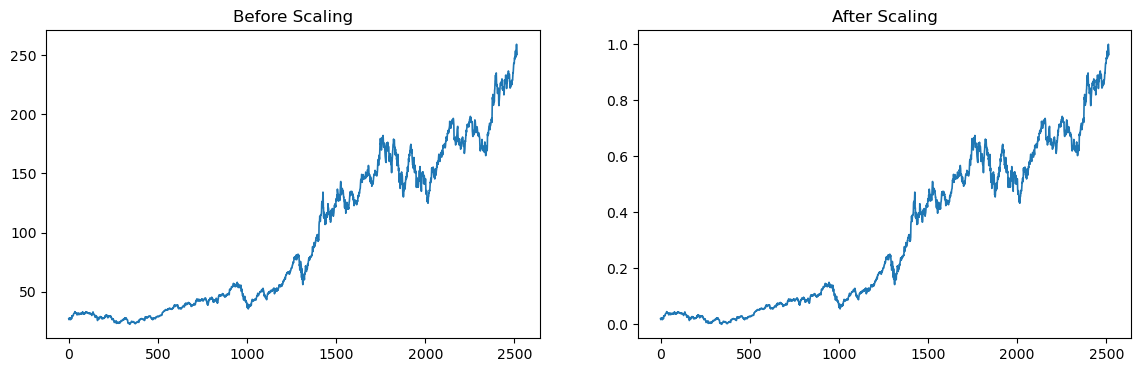

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(close_prices, linewidth=1.2)
axes[0].set_title('Before Scaling')
axes[1].plot(demo_scaled, linewidth=1.2)
axes[1].set_title('After Scaling')
plt.show()

In [71]:
SEQ_LEN = 60

def create_sequences(data: np.ndarray, seq_len: int):
    X, y = [], []

    for i in range(len(data) - seq_len):
        window = data[i : i + seq_len]
        target = data[i + seq_len]

        X.append(window)
        y.append(target)

    return np.array(X), np.array(y)

tiny_example = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6]).reshape(-1, 1)
tiny_X, tiny_y = create_sequences(tiny_example, seq_len=3)
print(tiny_X.squeeze())
print(tiny_y.squeeze())

[[0.1 0.2 0.3]
 [0.2 0.3 0.4]
 [0.3 0.4 0.5]]
[0.4 0.5 0.6]


In [72]:
train_size = int(len(close_prices) * 0.8)

train_raw = close_prices[:train_size]
test_raw = close_prices[train_size:]

print(f"Total days: {len(close_prices)}")
print(f"Train days: {len(train_raw)}")
print(f"Test days: {len(test_raw)}")

Total days: 2516
Train days: 2012
Test days: 504


In [73]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
test_scaled = scaler.transform(test_raw)

In [74]:
print('Train scaled range:', train_scaled.min(), train_scaled.max())
print('Test scaled range:', test_scaled.min(),test_scaled.max())

Train scaled range: 0.0 1.0
Test scaled range: 0.6425278375402401 1.4830484348004151


In [75]:
X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_test, y_test = create_sequences(test_scaled, SEQ_LEN)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1952, 60, 1) (1952, 1)
(444, 60, 1) (444, 1)


In [76]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [77]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StockDataset(X_train_tensor, y_train_tensor)
test_dataset = StockDataset(X_test_tensor, y_test_tensor)

In [78]:
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [79]:
sample_X, sample_y = next(iter(train_loader))
print('One batch of X shape:', sample_X.shape)
print('One batch of y shape:', sample_y.shape)
print('Number of batch per epoch:', len(train_loader))

One batch of X shape: torch.Size([32, 60, 1])
One batch of y shape: torch.Size([32, 1])
Number of batch per epoch: 61


In [96]:
class GRUModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2,
        output_size=1,
        dropout=0.2
    ):
        super(GRUModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size, output_size)

    # ✅ This must be at the same indentation level as __init__
    def forward(self, X):

        out, h_n = self.gru(X)

        # Take output from the last time step
        last_step_out = out[:, -1, :]

        last_step_out = self.dropout(last_step_out)

        prediction = self.fc(last_step_out)

        return prediction


INPUT_SIZE = 1
HIDDEN_SIZE = 64
NUM_LAYERS = 2
OUTPUT_SIZE = 1
DROPOUT = 0.2

model = GRUModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=OUTPUT_SIZE,
    dropout=DROPOUT,
)

print(model)

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [97]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total number of trainable parameters: {trainable_params}")

Total number of parameters: 37889
Total number of trainable parameters: 37889


In [98]:
model.eval()

with torch.no_grad():
    sample_X, sample_y = next(iter(train_loader))
    print("1) Input shape:", sample_X.shape)

    gru_out, h_n = model.gru(sample_X)
    print("2) GRU output shape:", gru_out.shape)
    print("3) Final hidden stage shape:", h_n.shape)

    last_step = gru_out[:,-1,:]
    print("4) Last time step shape:", last_step.shape)

    prediction = model.fc(last_step)
    print("5) Prediction shape:", prediction.shape)

model.train()

1) Input shape: torch.Size([32, 60, 1])
2) GRU output shape: torch.Size([32, 60, 64])
3) Final hidden stage shape: torch.Size([2, 32, 64])
4) Last time step shape: torch.Size([32, 64])
5) Prediction shape: torch.Size([32, 1])


GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [99]:
criterion = nn.MSELoss()
LEARNING_RATE = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [101]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

if device.type == 'cuda':
    print('GPU name:', torch.cuda.get_device_name(0))
else:
    print('No GPU detected - running on CPU')

Using device: cpu
No GPU detected - running on CPU


In [102]:
model = model.to(device)

In [103]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [104]:
NUM_EPOCHS = 50
BEST_MODEL_PATH = "best_gru_model.pth"

train_losses = []
test_losses = []
best_test_loss = float('inf')

for epoch in range(1, NUM_EPOCHS + 1):
  model.train()
  running_loss = 0.0

  progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=False)

  for X_batch, y_batch in progress_bar:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    optimizer.zero_grad()
    predictions = model(X_batch)
    loss = criterion(predictions, y_batch)
    loss.backward()
    optimizer.step()
    running_loss += loss.item() * X_batch.size(0)

    progress_bar.set_postfix({'Train Loss': running_loss / len(train_loader.dataset)})

  epoch_train_loss = running_loss / len(train_loader.dataset)
  train_losses.append(epoch_train_loss)

  epoch_test_loss = evaluate(model, test_loader, criterion, device)
  test_losses.append(epoch_test_loss)

  if epoch_test_loss < best_test_loss:
    best_test_loss= epoch_test_loss
    torch.save(model.state_dict(), BEST_MODEL_PATH)

  print(f"Epoch {epoch}/{NUM_EPOCHS} - Train Loss: {epoch_train_loss:.4f} - Test Loss: {epoch_test_loss:.4f}")

Epoch 1/50 - Train Loss: 0.0082 - Test Loss: 0.0674


Epoch 2/50 - Train Loss: 0.0774 - Test Loss: 0.0097


Epoch 3/50 - Train Loss: 0.0714 - Test Loss: 0.0096


Epoch 4/50 - Train Loss: 0.0258 - Test Loss: 0.0097


Epoch 5/50 - Train Loss: 0.0048 - Test Loss: 0.0134


...

Epoch 46/50 - Train Loss: 0.0027 - Test Loss: 0.0075


Epoch 47/50 - Train Loss: 0.0023 - Test Loss: 0.0061


Epoch 48/50 - Train Loss: 0.0024 - Test Loss: 0.0069


Epoch 49/50 - Train Loss: 0.0025 - Test Loss: 0.0070


Epoch 50/50 - Train Loss: 0.0019 - Test Loss: 0.0056


In [105]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

<All keys matched successfully>

In [106]:
model.eval()

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [108]:
all_predictions_scaled = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        batch_predictions = model(X_batch)
        all_predictions_scaled.append(batch_predictions.cpu().numpy())

predictions_scaled = np.concatenate(all_predictions_scaled, axis=0)
print("Scaled predictions shape:", predictions_scaled.shape)
print("First 5 scaled predictions:", predictions_scaled[:5].flatten())

Scaled predictions shape: (444, 1)
First 5 scaled predictions: [0.89689225 0.8951209  0.89975846 0.9051453  0.9128644 ]


In [109]:
predictions_actual = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test)

print("First 5 predicted prices (USD):", predictions_actual[:5].flatten())
print("First 5 actual price (USD):", y_test_actual[:5].flatten())

First 5 predicted prices (USD): [165.57205 165.28966 166.02899 166.88779 168.11841]
First 5 actual price (USD): [157.6499939  160.77000427 162.36000061 164.8999939  166.16999817]


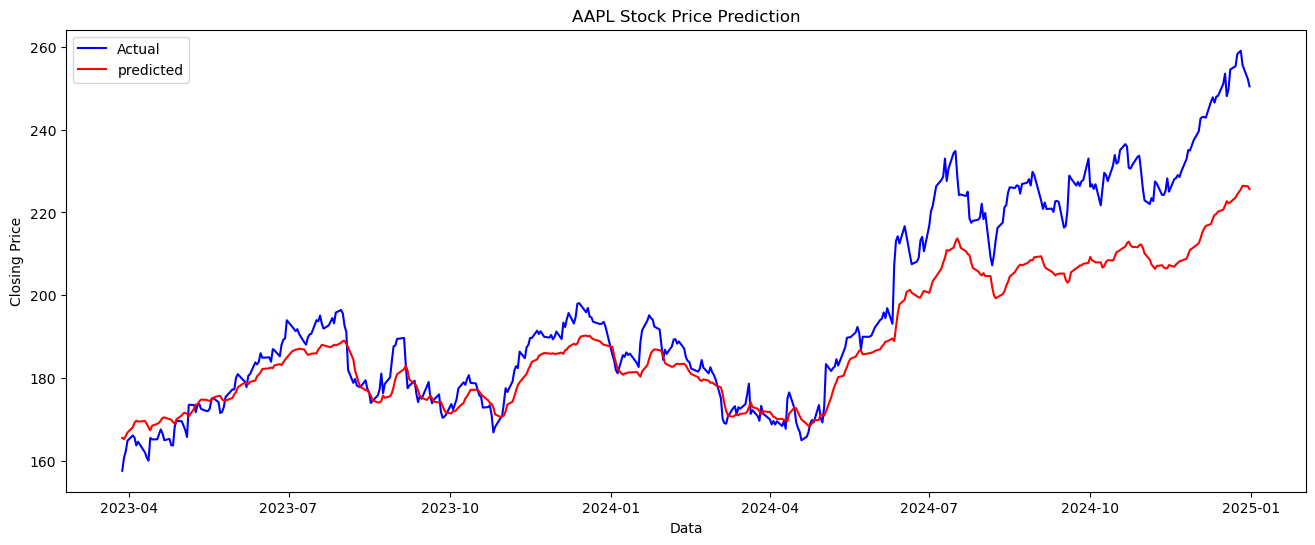

In [111]:
test_dataset = df['Date'].iloc[train_size + SEQ_LEN : train_size + SEQ_LEN + len(y_test_actual)].reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(test_dataset, y_test_actual, label='Actual', color='blue')
plt.plot(test_dataset, predictions_actual, label='predicted', color='red')
plt.title(f"{TICKER} Stock Price Prediction")
plt.xlabel('Data')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

In [112]:
mae = mean_absolute_error(y_test_actual, predictions_actual)
mse = mean_squared_error(y_test_actual, predictions_actual)
rmse = math.sqrt(mse)

mape = np.mean(np.abs((y_test_actual - predictions_actual) / y_test_actual)) * 100

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 8.70
MSE: 143.20
RMSE: 11.97
MAPE: 4.06%


In [113]:
def predict_future(model, last_window_scaled, num_days, scaler, device):
    model.eval()
    current_window = last_window_scaled.copy()
    future_predictions_scaled = []

    with torch.no_grad():
        for _ in range(num_days):
            input_tensor = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)
            next_pred_scaled = model(input_tensor).cpu().numpy()
            future_predictions_scaled.append(next_pred_scaled[0,0])
            current_window = np.append(current_window[1:], next_pred_scaled, axis=0)

    future_predictions_actual = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

    return future_predictions_actual

full_scaled_series = scaler.transform(close_prices)
last_60_days_sacled = full_scaled_series[-SEQ_LEN:]

NUM_FUTURE_DAYS = 20
future_prices = predict_future(model, last_60_days_sacled, NUM_FUTURE_DAYS, scaler, device)

last_known_date = df['Date'].iloc[-1]
future_dates = pd.bdate_range(start=last_known_date + pd.Timedelta(days=1), periods=NUM_FUTURE_DAYS)

future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Price': future_prices.flatten()
})

print(future_df)

         Date  Predicted Price
0  2025-01-01       224.970795
1  2025-01-02       218.784378
2  2025-01-03       213.902466
3  2025-01-06       209.507858
4  2025-01-07       205.394409
5  2025-01-08       201.472336
6  2025-01-09       197.782532
7  2025-01-10       194.336685
8  2025-01-13       191.064911
9  2025-01-14       187.967590
10 2025-01-15       185.081329
11 2025-01-16       182.416275
12 2025-01-17       179.978058
13 2025-01-20       177.685486
14 2025-01-21       175.566818
15 2025-01-22       173.626038
16 2025-01-23       171.889175
17 2025-01-24       170.366608
18 2025-01-27       169.022552
19 2025-01-28       167.829666


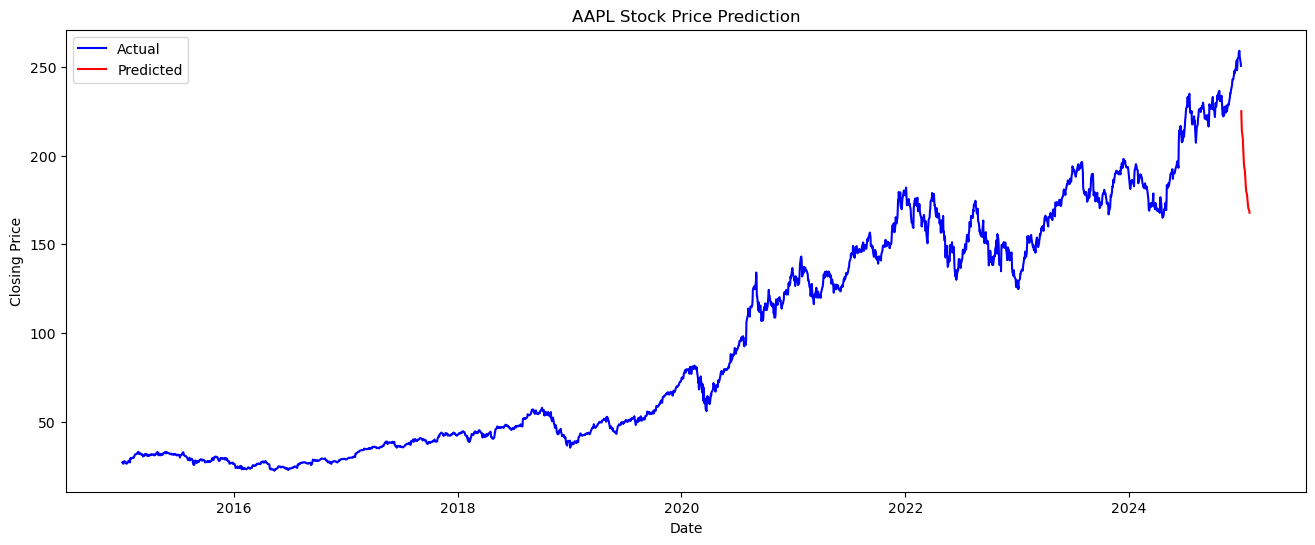

In [115]:
plt.figure(figsize=(16, 6))
plt.plot(df['Date'], df['Close'], label='Actual', color='blue')
plt.plot(future_df['Date'], future_df['Predicted Price'], label='Predicted', color='red')
plt.title(f"{TICKER} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

In [116]:
'''
Transformer Steps

Step 1 : Input Sentence

Step 2 : Input Embedding

Step 3 : Positional Encoding

Step 4 : Encoder Layer

Step 5 : Multi-Head Self Attention

Step 6 : Multi-Head Attention

Step 7 : Add & Norm

Step 8 : Feed Forward Network

Step 9 : Encoder Output

Step 10 : Decoder Input

Step 11 : Output Embedding

Step 12 : Masked Multi-Head Attention

Step 13 : Encoder - Decoder Attention (Cross Attention)

Step 14 : Feed Forward + Add & Norm

Step 15 : Linear Layer

Step 16 : Softmax

Step 17 : Autoregressive Generation
'''

'\nTransformer Steps\n\nStep 1 : Input Sentence\n\nStep 2 : Input Embedding\n\nStep 3 : Positional Encoding\n\nStep 4 : Encoder Layer\n\nStep 5 : Multi-Head Self Attention\n\nStep 6 : Multi-Head Attention\n\nStep 7 : Add & Norm\n\nStep 8 : Feed Forward Network\n\nStep 9 : Encoder Output\n\nStep 10 : Decoder Input\n\nStep 11 : Output Embedding\n\nStep 12 : Masked Multi-Head Attention\n\nStep 13 : Encoder - Decoder Attention (Cross Attention)\n\nStep 14 : Feed Forward + Add & Norm\n\nStep 15 : Linear Layer\n\nStep 16 : Softmax\n\nStep 17 : Autoregressive Generation\n'

In [117]:
'''
Stages in CNN

Stage 1 : Input Image

Stage 2 : Kernel

Stage 3 : Convolution

Stage 4 : ReLU Activation

Stage 5 : Pooling

Stage 6 : Repeating Convolution + ReLU + Pooling (Feature Extraction)

Stage 7 : Flatten Layer

Stage 8 : Fully Connected Layer

Stage 9 : Softmax Activation Function
'''

'\nStages in CNN\n\nStage 1 : Input Image\n\nStage 2 : Kernel\n\nStage 3 : Convolution\n\nStage 4 : ReLU Activation\n\nStage 5 : Pooling\n\nStage 6 : Repeating Convolution + ReLU + Pooling (Feature Extraction)\n\nStage 7 : Flatten Layer\n\nStage 8 : Fully Connected Layer\n\nStage 9 : Softmax Activation Function\n'